In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler

In [2]:
df = pd.read_csv('../dataset/ghi_temp.csv')

In [3]:
df.head()

,Year,Month,Day,Hour,Minute,GHI,Temperature,Unnamed: 7,Unnamed: 8,Unnamed: 9,Unnamed: 10,Unnamed: 11,Unnamed: 12,Unnamed: 13,Unnamed: 14
0,2019,1,1,0,0,0,16.3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2019,1,1,1,0,0,16.2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2019,1,1,2,0,0,16.1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2019,1,1,3,0,0,16.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2019,1,1,4,0,0,15.9,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [4]:
ghi_col = ['Year', 'Month', 'Day', 'Hour', 'Minute', 'GHI', 'Temperature']
df = df[ghi_col]
df.head()

,Year,Month,Day,Hour,Minute,GHI,Temperature
0,2019,1,1,0,0,0,16.3
1,2019,1,1,1,0,0,16.2
2,2019,1,1,2,0,0,16.1
3,2019,1,1,3,0,0,16.0
4,2019,1,1,4,0,0,15.9


In [5]:
df['datetime'] = pd.to_datetime(df[['Year', 'Month', 'Day', 'Hour', 'Minute']])

In [6]:
df.head()

,Year,Month,Day,Hour,Minute,GHI,Temperature,datetime
0,2019,1,1,0,0,0,16.3,2019-01-01 00:00:00
1,2019,1,1,1,0,0,16.2,2019-01-01 01:00:00
2,2019,1,1,2,0,0,16.1,2019-01-01 02:00:00
3,2019,1,1,3,0,0,16.0,2019-01-01 03:00:00
4,2019,1,1,4,0,0,15.9,2019-01-01 04:00:00


In [7]:
df = df[['datetime', 'GHI', 'Temperature']]

df.set_index('datetime', inplace=True)

df.head()

,GHI,Temperature
datetime,,
2019-01-01 00:00:00,0,16.3
2019-01-01 01:00:00,0,16.2
2019-01-01 02:00:00,0,16.1
2019-01-01 03:00:00,0,16.0
2019-01-01 04:00:00,0,15.9


In [8]:
print(df.shape)

(8760, 2)


In [9]:
data_features = df[['GHI', 'Temperature']].values
data_target = df['Temperature'].values

In [10]:
look_back = 24 #menggunakan timestamp 24
n_ahead = 1 # predict 1 jam berikutnya

x_seq = []
y_seq = []

for i in range(len(data_features) - look_back - n_ahead + 1):
    print("i: ", i)
    print("untuk x seq: ", i + look_back)
    print("i + lookback: ", i + look_back)
    print("i + look_back + n_ahead: ", i + look_back + n_ahead)
    x_seq.append(data_features[i : (i + look_back)]) # mengambil value 24 jam sebelum
    y_seq.append(data_target[(i + look_back) : (i + look_back + n_ahead)]) #mengambil value 1 jam berikutnya

x_seq, y_seq = np.array(x_seq), np.array(y_seq)

i:  0
untuk x seq:  24
i + lookback:  24
i + look_back + n_ahead:  25
i:  1
untuk x seq:  25
i + lookback:  25
i + look_back + n_ahead:  26
i:  2
untuk x seq:  26
i + lookback:  26
i + look_back + n_ahead:  27
i:  3
untuk x seq:  27
i + lookback:  27
i + look_back + n_ahead:  28
i:  4
untuk x seq:  28
i + lookback:  28
i + look_back + n_ahead:  29
i:  5
untuk x seq:  29
i + lookback:  29
i + look_back + n_ahead:  30
i:  6
untuk x seq:  30
i + lookback:  30
i + look_back + n_ahead:  31
i:  7
untuk x seq:  31
i + lookback:  31
i + look_back + n_ahead:  32
i:  8
untuk x seq:  32
i + lookback:  32
i + look_back + n_ahead:  33
i:  9
untuk x seq:  33
i + lookback:  33
i + look_back + n_ahead:  34
i:  10
untuk x seq:  34
i + lookback:  34
i + look_back + n_ahead:  35
i:  11
untuk x seq:  35
i + lookback:  35
i + look_back + n_ahead:  36
i:  12
untuk x seq:  36
i + lookback:  36
i + look_back + n_ahead:  37
i:  13
untuk x seq:  37
i + lookback:  37
i + look_back + n_ahead:  38
i:  14
untuk x s

In [11]:
print(x_seq.shape)
print(y_seq.shape)

(8736, 24, 2)
(8736, 1)


In [12]:
split_point = int(len(x_seq) * 0.8) # 80% for training and 20% for testing

x_train, x_test = x_seq[:split_point], x_seq[split_point:]
y_train, y_test = y_seq[:split_point], y_seq[split_point:]

#flatten the y

y_train = y_train.flatten()
y_test = y_test.flatten()

print(f'x_train shape: {x_train.shape}, x_test shape: {x_test.shape}')
print(f'y_train shape: {y_train.shape}, y_test shape: {y_test.shape}')

x_train shape: (6988, 24, 2), x_test shape: (1748, 24, 2)
y_train shape: (6988,), y_test shape: (1748,)


In [13]:
from sklearn.preprocessing import StandardScaler, RobustScaler

scaler_x = RobustScaler()
scaler_y = RobustScaler()

#fit dan transform the training data
#kalau mau fit transform, data harus 2 dimensi. untuk x, kembalikan ke 3 dimensi. untuk y, kembalikan 1 dimensi
x_train_scaled = scaler_x.fit_transform(x_train.reshape(-1, 2)).reshape(x_train.shape[0], x_train.shape[1], 2) 
y_train_scaled = scaler_y.fit_transform(y_train.reshape(-1, 1))
y_train_scaled = y_train_scaled.flatten()

# tranform the testing data
x_test_scaled = scaler_x.fit_transform(x_test.reshape(-1, 2)).reshape(x_test.shape[0], x_test.shape[1], 2)
y_test_scaled = scaler_y.transform(y_test.reshape(-1, 1))
y_test_scaled = y_test_scaled.flatten()

# # Reshape X_train and X_test to 3D for LSTM input (samples, time steps, features)
# X_train_scaled = X_train.reshape(X_train_scaled.shape[0], X_train_scaled.shape[1], 1)
# X_test_scaled = X_test_scaled.reshape(X_test_scaled.shape[0], X_test_scaled.shape[1], 1)

# Check the shapes after standardization
print(f'X_train_scaled shape: {x_train_scaled.shape}, X_test_scaled shape: {x_test_scaled.shape}')
print(f'y_train_scaled shape: {y_train_scaled.shape}, y_test_scaled shape: {y_test_scaled.shape}')

X_train_scaled shape: (6988, 24, 2), X_test_scaled shape: (1748, 24, 2)
y_train_scaled shape: (6988,), y_test_scaled shape: (1748,)


In [14]:
import tensorflow as tf

In [15]:
#define the sequential LSTM model with tf.keras.Input layer

model = tf.keras.Sequential()
model.add(tf.keras.Input(shape=(look_back, 2))) #explicit input layer using tf.keras.input (timesteps, features)

#add LSTM layers with dropout and regularization
model.add(tf.keras.layers.LSTM(128)) #LSTM layer with 50 units and L2
model.add(tf.keras.layers.Dropout(0.2)) #dropout layer with 20%

# Output layer for 1 target step
model.add(tf.keras.layers.Dense(1))

# Compile the model
model.compile(optimizer='adam', loss='mse')

# Model summary to show architecture
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 128)            │        67,072 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 67,201 (262.50 KB)

 Trainable params: 67,201 (262.50 KB)

 Non-trainable params: 0 (0.00 B)

In [16]:
# Train the model
history = model.fit(x_train_scaled , y_train_scaled, epochs=10, batch_size=150, validation_split=0.2, shuffle=False)

Epoch 1/10
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 25ms/step - loss: 0.2374 - val_loss: 0.0274
Epoch 2/10
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 0.1100 - val_loss: 0.0157
Epoch 3/10
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0460 - val_loss: 0.0114
Epoch 4/10
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - loss: 0.0234 - val_loss: 0.0082
Epoch 5/10
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 0.0176 - val_loss: 0.0067
Epoch 6/10
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0170 - val_loss: 0.0055
Epoch 7/10
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - loss: 0.0176 - val_loss: 0.0063
Epoch 8/10
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - loss: 0.0193 - val_loss: 0.0061
Epoch 9/10
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - loss: 0.0201 - val_loss: 0.0059
Epoch 10/10
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - loss: 0.0208 - val_loss: 0.0052


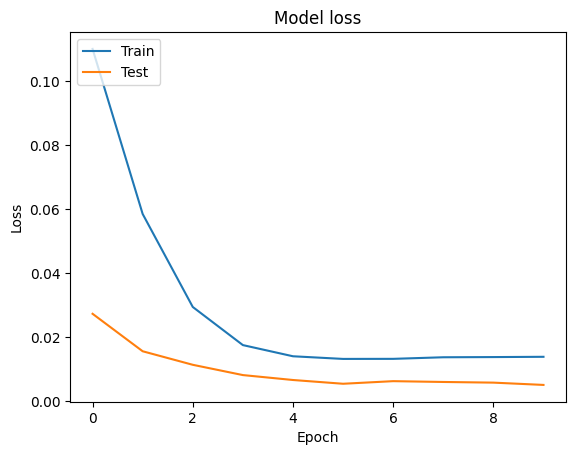

In [17]:
# prompt: plot the loss history of training and validation

# Plot training & validation loss values
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Test'], loc='upper left')
plt.show()

In [18]:
#Evaluate the model

test_loss = model.evaluate(x_test_scaled, y_test_scaled)
print(f"Test Loss: {test_loss}")

55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.6139
Test Loss: 0.42759937047958374


In [19]:
# Make predictions on the test set
y_pred_scaled = model.predict(x_test_scaled)

# De-standardize the predictions using the same scaler as for y
y_pred = scaler_y.inverse_transform(y_pred_scaled).flatten()

# De-standardize the actual values
y_test = scaler_y.inverse_transform(y_test_scaled.reshape(-1, 1)).flatten()


55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step


In [20]:
from sklearn.metrics import mean_squared_error, mean_absolute_error

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)

print(f'Mean Absolute Error (MAE): {mae}')
print(f'Mean Squared Error (MSE): {mse}')

Mean Absolute Error (MAE): 4.36290201453377
Mean Squared Error (MSE): 24.052463106797045


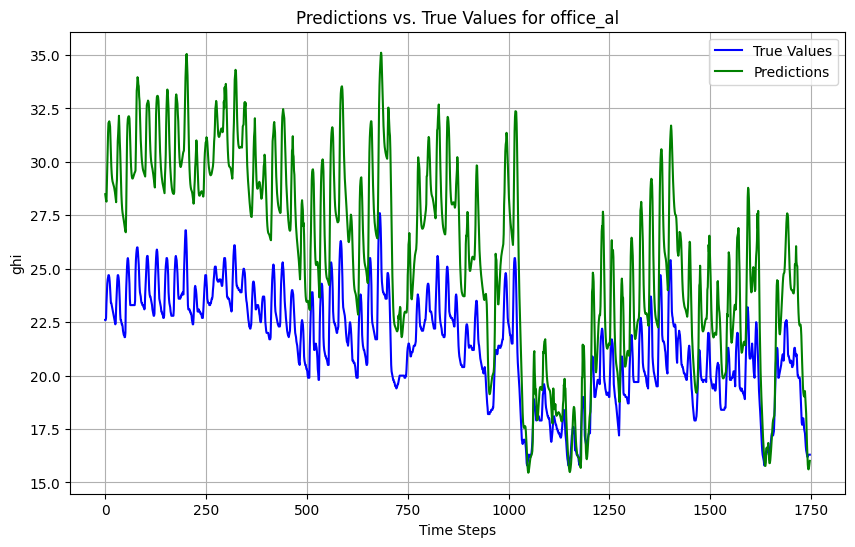

In [21]:
# prompt: plot the prediction vs true test

# Plot the predictions vs. true values
plt.figure(figsize=(10, 6))
plt.plot(y_test, label='True Values', color='blue')
plt.plot(y_pred, label='Predictions', color='green')
plt.title('Predictions vs. True Values for office_al')
plt.xlabel('Time Steps')
plt.ylabel('ghi')
plt.legend()
plt.grid(True)
plt.show()

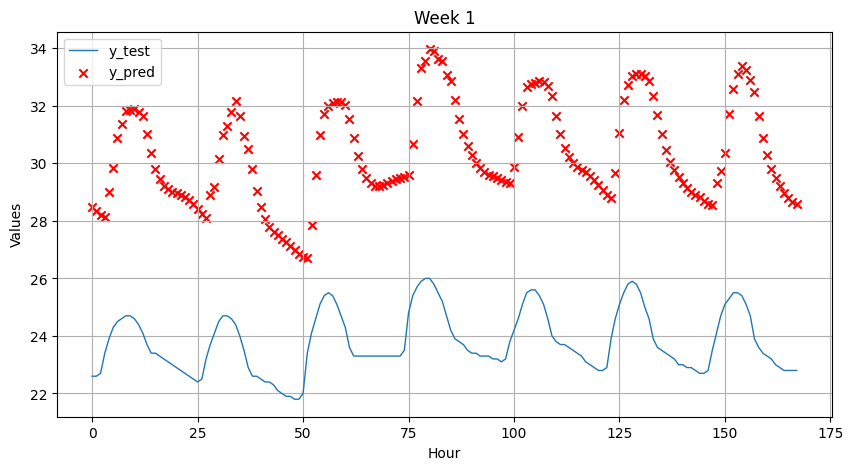

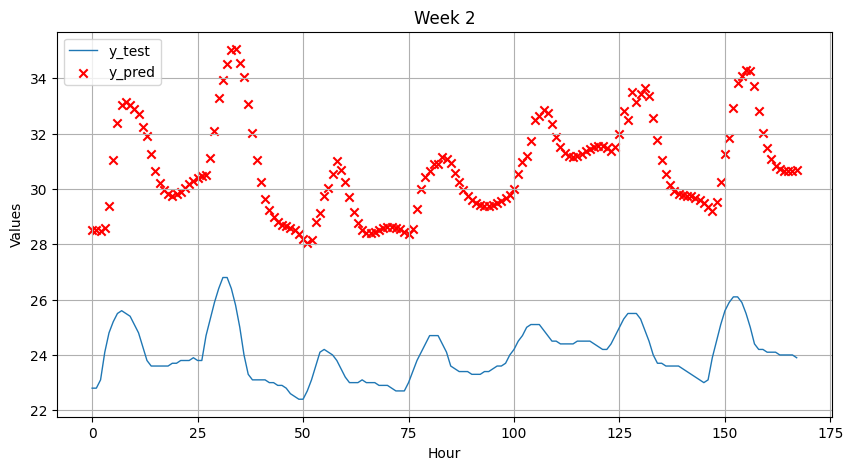

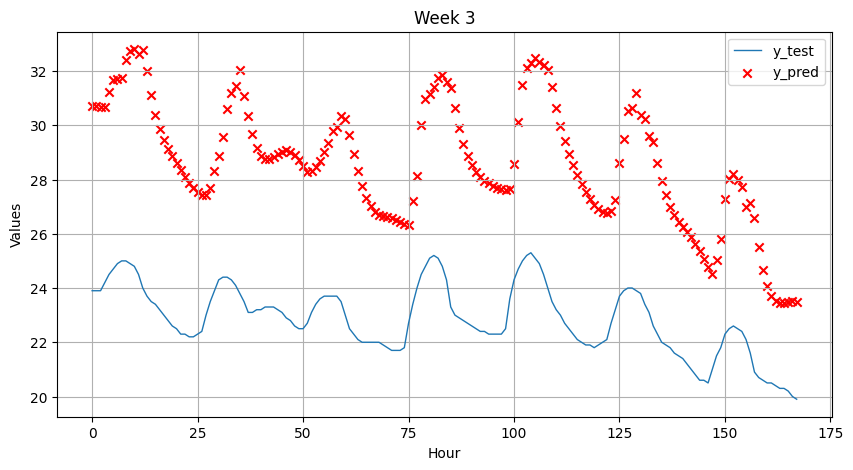

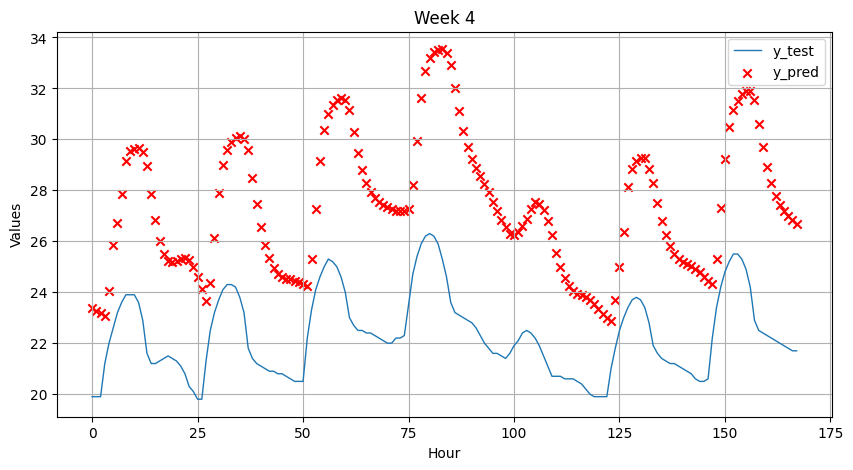

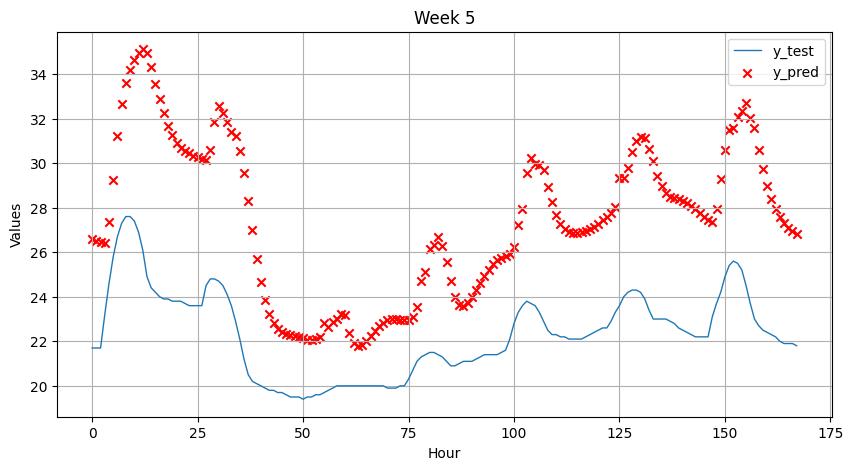

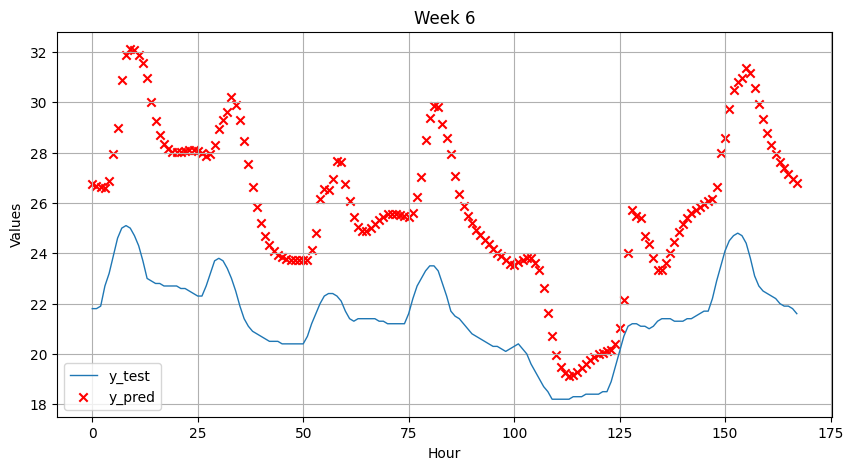

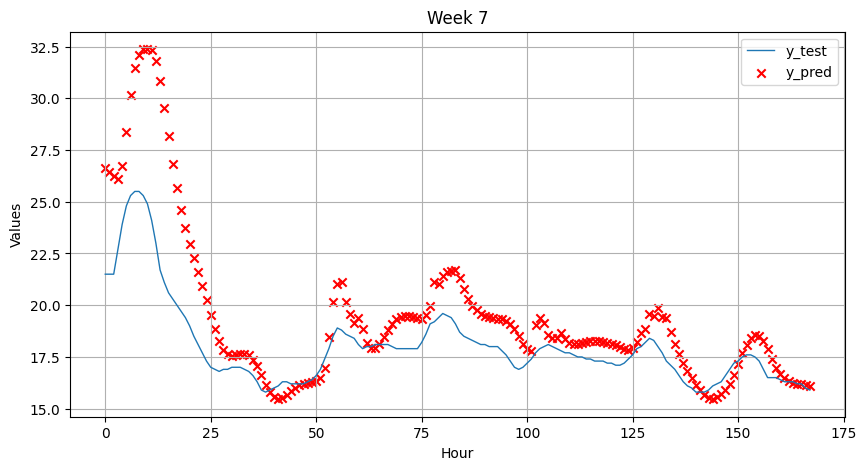

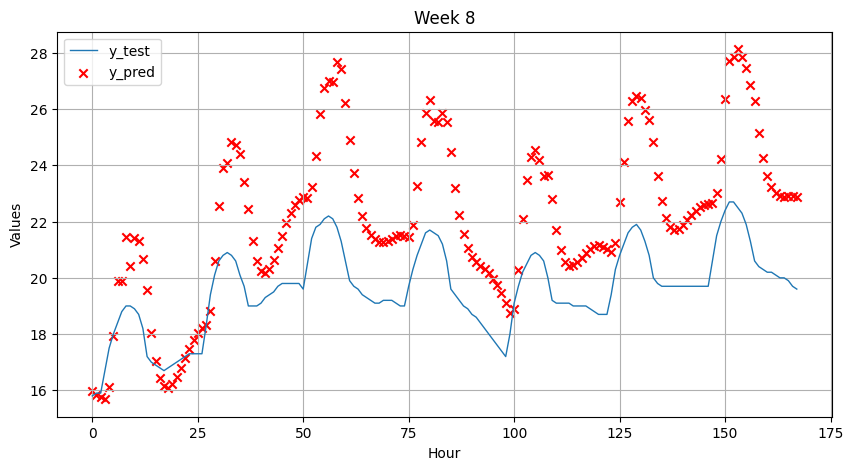

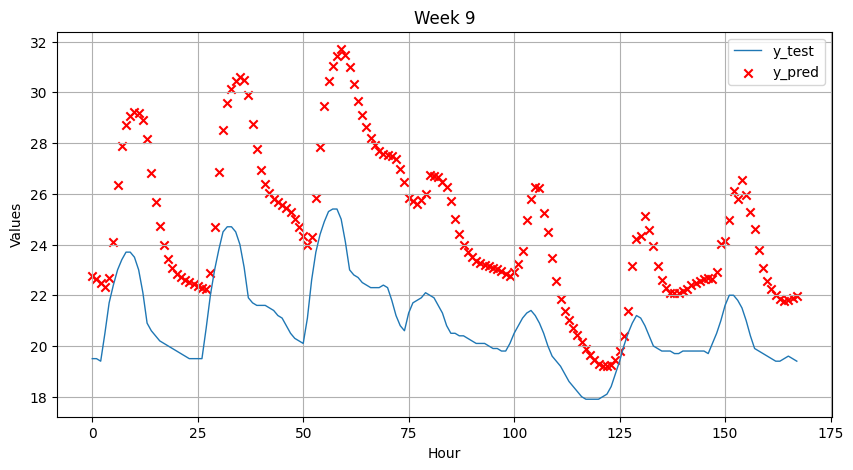

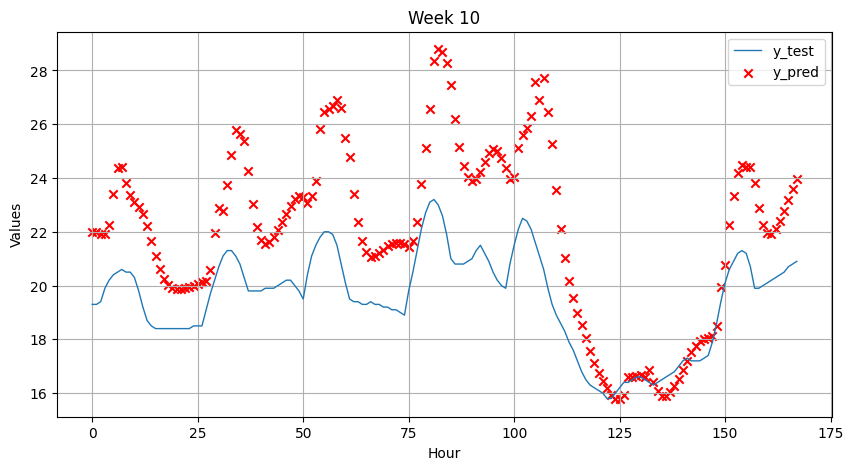

In [22]:
hours_per_week = 24 * 7

num_weeks = len(y_pred) // hours_per_week

for week in range(num_weeks):
    start_idx = week * hours_per_week
    end_idx = start_idx + hours_per_week
    plt.figure(figsize=(10, 5))  # Set ukuran figure
    plt.plot(y_test[start_idx:end_idx], label='y_test', linewidth=1)
    plt.scatter(range(hours_per_week), y_pred[start_idx:end_idx], color='red', marker='x', label='y_pred')
    plt.title(f'Week {week + 1}')
    plt.xlabel('Hour')
    plt.ylabel('Values')
    plt.legend()
    plt.grid(True)
    plt.show()